# Outpainting (Expansão de Imagens)

Este notebook fornece uma rotina prática para realizar outpainting (expansão contextual de imagens) usando pipelines de inpainting do `diffusers`.

Inclui: preparação de canvas (expansão), geração da máscara apropriada, execução do pipeline de inpainting e recomendações de modelos e parâmetros.

## 1. Observações iniciais
- Recomendações de modelos: `runwayml/stable-diffusion-inpainting` (leve) ou `stabilityai/stable-diffusion-xl-inpainting` (SDXL - melhor qualidade).
- Certifique-se de ter `diffusers`, `transformers` e `torch` instalados (veja `requirements.txt`).
- Ajuste `expand_px` para controlar quanto o canvas será expandido (ex.: 200–800 px).

In [2]:
# Imports e configuração básica
from PIL import Image, ImageOps, ImageFilter
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

# Ajuste aqui o modelo que deseja usar
# Use 'runwayml/stable-diffusion-inpainting' para execução leve
# Ou 'stabilityai/stable-diffusion-xl-inpainting' se tiver VRAM e quiser melhor qualidade
MODEL_ID = 'runwayml/stable-diffusion-inpainting'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print('Device:', DEVICE)
print('Model id (edit MODEL_ID to change):', MODEL_ID)

Device: cpu
Model id (edit MODEL_ID to change): runwayml/stable-diffusion-inpainting


## 2. Funções utilitárias
Contém funções para expandir o canvas, criar a máscara e mostrar resultados.

In [3]:
def expand_canvas_and_mask(image: Image.Image, expand_left=0, expand_right=0, expand_top=0, expand_bottom=0, fill_color=(255,255,255)) -> (Image.Image, Image.Image):
    """Expande a tela e retorna (canvas_rgb, mask_l).

    A máscara é '255' nas regiões a inpaint e '0' nas regiões a preservar.
    Por convenção aqui: branca = área a gerar (inpaint).
    """
    w, h = image.size
    new_w = w + expand_left + expand_right
    new_h = h + expand_top + expand_bottom

    canvas = Image.new('RGB', (new_w, new_h), fill_color)
    # position to paste original image
    paste_x = expand_left
    paste_y = expand_top
    canvas.paste(image, (paste_x, paste_y))

    # máscara: começar preenchida (255) para gerar o que está fora da imagem original
    mask = Image.new('L', (new_w, new_h), 255)
    # preservar (0) a região onde a imagem original está colada
    mask.paste(0, box=(paste_x, paste_y, paste_x + w, paste_y + h))

    return canvas, mask


def show_images_grid(images, titles=None, figsize=(12,6)):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for i,img in enumerate(images):
        axes[i].imshow(img) if not isinstance(img, Image.Image) else axes[i].imshow(img)
        if titles and i < len(titles):
            axes[i].set_title(titles[i])
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()


## 3. Carregamento do pipeline e execução de outpainting

Esta célula carrega o pipeline `StableDiffusionInpaintPipeline` do `diffusers` e faz a inferência.

In [4]:
# Carregar pipeline (pode demorar). Troque MODEL_ID se quiser SDXL.
from diffusers import StableDiffusionInpaintPipeline

print('Loading pipeline:', MODEL_ID)
pipe = StableDiffusionInpaintPipeline.from_pretrained(MODEL_ID, torch_dtype=torch.float32)
pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()
# garantir float32 em componentes críticos
pipe.vae = pipe.vae.float()
try:
    pipe.enable_vae_tiling()
except Exception:
    pass


def run_outpaint(pipe, canvas: Image.Image, mask: Image.Image, prompt: str, negative_prompt: str = '', num_inference_steps=40, guidance_scale=7.5, seed: int | None = None):
    if seed is not None:
        generator = torch.Generator(device=DEVICE).manual_seed(int(seed))
    else:
        generator = None

    # Alguns pipelines esperam mask_image com 255 indicando regiões a inpaint.
    # Ajuste aqui se seu pipeline interpretar ao contrário (ImageOps.invert).
    with torch.no_grad():
        out = pipe(prompt=prompt, image=canvas, mask_image=mask, negative_prompt=negative_prompt,
                   num_inference_steps=num_inference_steps, guidance_scale=guidance_scale, generator=generator)
    return out.images[0]


/home/gabrielmontagna/.venvs/venv-MC949-T4/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading pipeline: runwayml/stable-diffusion-inpainting


Loading pipeline components...:  57%|█████▋    | 4/7 [00:09<00:06,  2.04s/it]An error occurred while trying to fetch /home/gabrielmontagna/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/gabrielmontagna/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  71%|███████▏  | 5/7 [00:09<00:02,  1.45s/it]An error occurred while trying to fetch /home/gabrielmontagna/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/gabrielmontagna/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpai

## 4. Exemplo de uso

Substitua `INPUT_PATH` pela sua imagem de teste. Ajuste `expand_*` para escolher onde expandir.

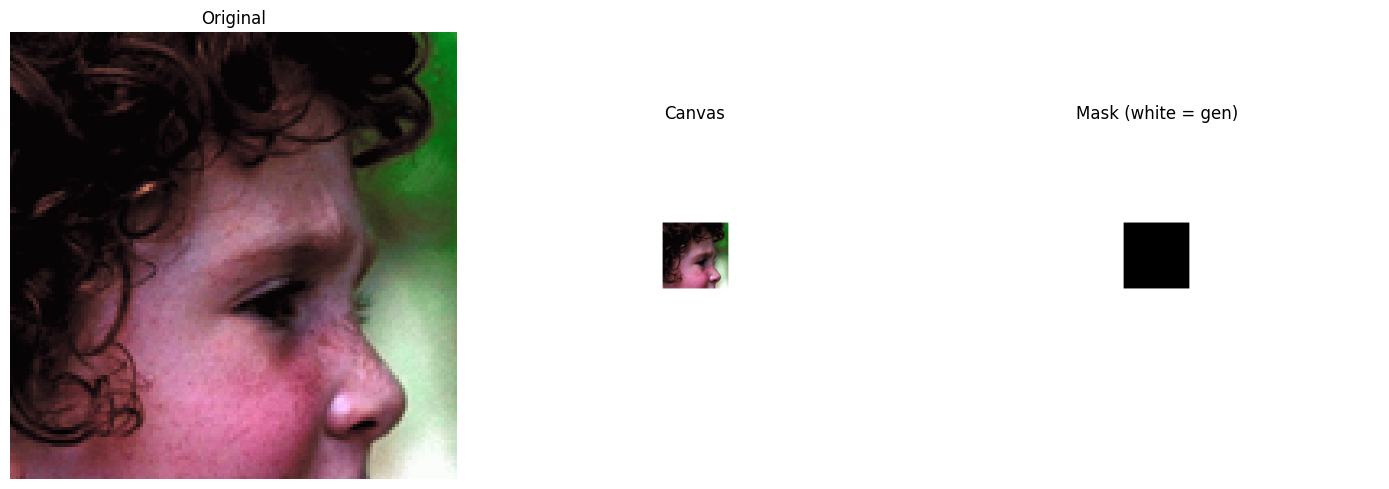

100%|██████████| 40/40 [13:56<00:00, 20.91s/it]


Saved: Set14dataset/outpainting_result.png


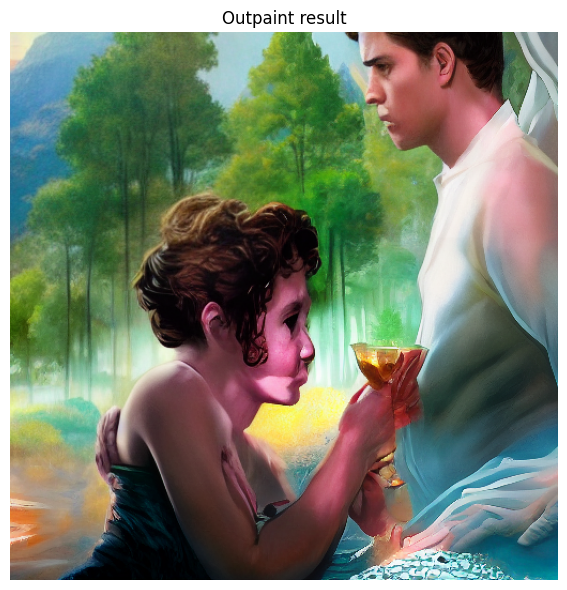

In [5]:
# Parâmetros de exemplo
INPUT_PATH = '/mnt/c/Users/gabri/Documents/2025/2sem/MC949_Visao_Computacional/Trabalho 4/Set14dataset/image_SRF_2/img_006_SRF_2_LR.png'  # troque para sua imagem
OUTPUT_PATH = 'Set14dataset/outpainting_result.png'
# Expansão (esquerda, direita, topo, base) em pixels
expand_left = 400
expand_right = 400
expand_top = 200
expand_bottom = 200
prompt = 'A natural continuation of the scene, realistic, harmonious colors and lighting, high detail'
negative_prompt = 'text, watermark, low quality, artifacts'
seed = 42

# Load image
if not os.path.exists(INPUT_PATH):
    raise FileNotFoundError(f'Input image not found: {INPUT_PATH}')
orig = Image.open(INPUT_PATH).convert('RGB')
canvas, mask = expand_canvas_and_mask(orig, expand_left, expand_right, expand_top, expand_bottom)

show_images_grid([orig, canvas, mask.convert('RGB')], titles=['Original', 'Canvas', 'Mask (white = gen)'], figsize=(14,6))

# Run outpainting
result = run_outpaint(pipe, canvas, mask, prompt=prompt, negative_prompt=negative_prompt, num_inference_steps=40, guidance_scale=7.5, seed=seed)

# Salvar e mostrar
result.save(OUTPUT_PATH)
print('Saved:', OUTPUT_PATH)
show_images_grid([result], titles=['Outpaint result'], figsize=(6,6))

## 5. Notas finais e sugestões de experimento
- Se o seu pipeline interpretar a máscara ao contrário, use `mask = ImageOps.invert(mask)` antes da chamada.
- Para melhor coerência estrutural, experimente gerar um mapa de bordas (Canny) e usar `ControlNet` condicionalmente (requer implementação extra).
- Para qualidade máxima, troque `MODEL_ID` para SDXL Inpainting (`stabilityai/stable-diffusion-xl-inpainting`) se a GPU suportar.
- Documente prompts, seeds e parâmetros em CSV para o relatório.